<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `ExplicitStimulusWhiskerData.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now reproduces the dataset-backed lag search, stimulus-effect, and history-effect workflow with real figures; exact KS traces and coefficient values still vary modestly from MATLAB because the Python GLM backend and plotting defaults are different.


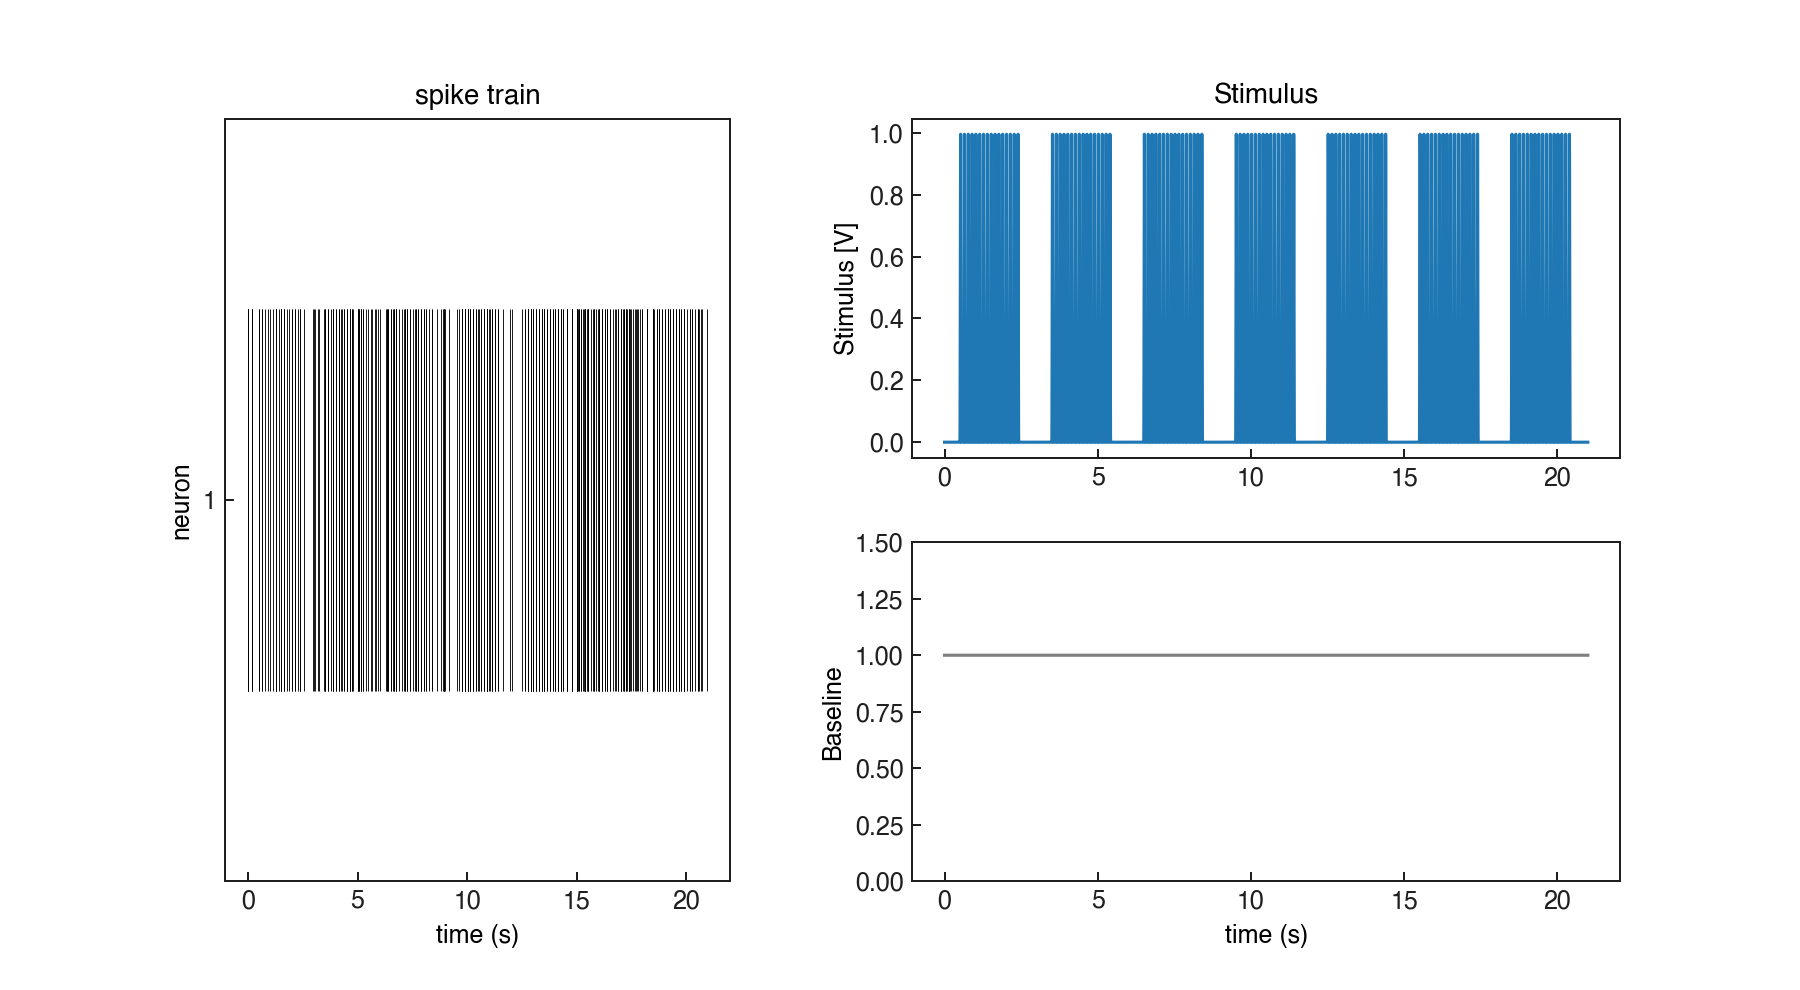

In [ ]:
# nSTAT-python notebook example: ExplicitStimulusWhiskerData
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_data import notebook_example_data_dir
from nstat.notebook_figures import FigureTracker
from nstat.paper_examples_full import run_experiment2

np.random.seed(0)
DATA_DIR = notebook_example_data_dir(allow_synthetic=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='ExplicitStimulusWhiskerData', output_root=OUTPUT_ROOT, expected_count=11)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _plot_spike_indicator(ax, time_s, spike_indicator):
    spike_times = np.asarray(time_s, dtype=float)[np.asarray(spike_indicator, dtype=float) > 0.5]
    if spike_times.size:
        ax.vlines(spike_times, 0.0, 1.0, color="k", linewidth=0.35)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("spikes")


def _plot_ks(ax, ideal, empirical, ci, *, label, color):
    ideal_arr = np.asarray(ideal, dtype=float)
    empirical_arr = np.asarray(empirical, dtype=float)
    ci_arr = np.asarray(ci, dtype=float)
    ax.plot(ideal_arr, ideal_arr, color="0.2", linewidth=1.0, linestyle="--", label="45° line")
    ax.plot(ideal_arr, empirical_arr, color=color, linewidth=1.5, label=label)
    ax.fill_between(
        ideal_arr,
        np.clip(ideal_arr - ci_arr, 0.0, 1.0),
        np.clip(ideal_arr + ci_arr, 0.0, 1.0),
        color="0.8",
        alpha=0.35,
        label="95% CI",
    )
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Empirical quantiles")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)


def _plot_results_dashboard(fig, payload, models):
    """Render MATLAB results.plotResults 5-panel layout (KS / ACF / SeqCorr / Coeffs / Residual).

    models: list of (label, color, ks_empirical, acf_vals, seq_corr_dict, glm_dict, residual_arr).
    """
    ks_ideal = np.asarray(payload["ks_ideal"], dtype=float)
    ks_ci = np.asarray(payload["ks_ci"], dtype=float)
    acf_lags = np.asarray(payload["acf_lags"], dtype=float)
    acf_ci = float(payload["acf_ci"])
    residual_t = np.asarray(payload["residual_t"], dtype=float)

    gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)
    ax_ks = fig.add_subplot(gs[0, 0])
    ax_acf = fig.add_subplot(gs[0, 1])
    ax_seq = fig.add_subplot(gs[0, 2])
    ax_glm = fig.add_subplot(gs[1, 0])
    ax_res = fig.add_subplot(gs[1, 1:])

    # KS plot — 45 line + per-model empirical + shared 95% CI
    ax_ks.plot(ks_ideal, ks_ideal, color="0.2", linestyle="--", linewidth=1.0, label="45°")
    ax_ks.fill_between(
        ks_ideal,
        np.clip(ks_ideal - ks_ci, 0.0, 1.0),
        np.clip(ks_ideal + ks_ci, 0.0, 1.0),
        color="0.8",
        alpha=0.35,
    )
    for label, color, ks_emp, *_ in models:
        ax_ks.plot(ks_ideal, np.asarray(ks_emp, dtype=float), color=color, linewidth=1.4, label=label)
    ax_ks.set_xlim(0.0, 1.0)
    ax_ks.set_ylim(0.0, 1.0)
    ax_ks.set_xlabel("Theoretical quantiles")
    ax_ks.set_ylabel("Empirical quantiles")
    ax_ks.set_title("KS plot (rescaled ISIs)")
    ax_ks.legend(loc="lower right", frameon=False, fontsize=7)

    # ACF
    for label, color, _ks, acf_vals, *_ in models:
        ax_acf.stem(acf_lags, np.asarray(acf_vals, dtype=float), linefmt=color, markerfmt=" ", basefmt="0.5")
    ax_acf.axhline(acf_ci, color="0.4", linestyle="--", linewidth=0.8)
    ax_acf.axhline(-acf_ci, color="0.4", linestyle="--", linewidth=0.8)
    ax_acf.set_xlabel("lag")
    ax_acf.set_ylabel("ACF of rescaled ISIs")
    ax_acf.set_title("Autocorrelation")

    # Sequential correlation u_{j+1} vs u_j
    annotation_lines = []
    for label, color, _ks, _acf, seq, *_ in models:
        ax_seq.plot(
            np.asarray(seq["uj"], dtype=float),
            np.asarray(seq["uj1"], dtype=float),
            ".",
            color=color,
            markersize=2.5,
            alpha=0.55,
        )
        annotation_lines.append(f"{label}: rho={seq['rho']:.3f}, p={seq['p']:.3g}")
    ax_seq.set_xlim(0.0, 1.0)
    ax_seq.set_ylim(0.0, 1.0)
    ax_seq.set_xlabel(r"$u_j$")
    ax_seq.set_ylabel(r"$u_{j+1}$")
    ax_seq.set_title("Sequential correlation")
    ax_seq.text(
        0.02,
        0.98,
        "\n".join(annotation_lines),
        transform=ax_seq.transAxes,
        va="top",
        fontsize=6,
        family="monospace",
    )

    # GLM coefficients with 95% CIs (one model per panel-row offset for readability)
    base_x = 0.0
    for shift_idx, (label, color, _ks, _acf, _seq, glm, *_) in enumerate(models):
        names = list(glm["names"])
        values = np.asarray(glm["values"], dtype=float)
        lower = np.asarray(glm["lower"], dtype=float)
        upper = np.asarray(glm["upper"], dtype=float)
        x = np.arange(len(names), dtype=float) + 0.12 * shift_idx
        ax_glm.errorbar(
            x,
            values,
            yerr=[values - lower, upper - values],
            fmt="o",
            color=color,
            markersize=3,
            linewidth=0.9,
            capsize=2,
            label=label,
        )
        base_x = max(base_x, float(len(names)))
    ax_glm.axhline(0.0, color="0.3", linewidth=0.8)
    last_glm = models[-1][5]
    ax_glm.set_xticks(np.arange(len(last_glm["names"])))
    ax_glm.set_xticklabels(list(last_glm["names"]), rotation=75, fontsize=6)
    ax_glm.set_ylabel("coefficient")
    ax_glm.set_title("GLM coefficients (95% CI)")
    ax_glm.legend(loc="best", frameon=False, fontsize=6)

    # Point-process residual M(t_k)
    for label, color, _ks, _acf, _seq, _glm, residual in models:
        ax_res.plot(residual_t, np.asarray(residual, dtype=float), color=color, linewidth=1.0, label=label)
    ax_res.axhline(0.0, color="0.3", linewidth=0.8)
    ax_res.set_xlabel("time (s)")
    ax_res.set_ylabel(r"M($t_k$) [Hz·s]")
    ax_res.set_title("Point process residual")
    ax_res.legend(loc="best", frameon=False, fontsize=7)

# EXPLICIT STIMULUS EXAMPLE - WHISKER STIMULATION/THALAMIC NEURON

In the worksheet with analyze the stimulus effect and history effect on the firing of a thalamic neuron under a known stimulus consisting of whisker stimulation. Data from Demba Ba (demba@mit.edu)

In [2]:
# SECTION 0: EXPLICIT STIMULUS EXAMPLE - WHISKER STIMULATION/THALAMIC NEURON
# This notebook follows the MATLAB helpfile workflow for explicit whisker-stimulation analysis.
plt.close("all")
summary, payload = run_experiment2(DATA_DIR, return_payload=True)
model_names = ["Baseline", "Baseline+Stimulus", "Baseline+Stimulus+History"]
best_history_idx = int(np.argmin(np.asarray(payload["delta_bic"], dtype=float)))
best_history_window = int(np.asarray(payload["history_windows"], dtype=float)[best_history_idx])
print(
    {
        "n_samples": int(summary["n_samples"]),
        "peak_lag_ms": round(float(summary["peak_lag_seconds"]) * 1000.0, 1),
        "best_history_window_bins": best_history_window,
    }
)


{'n_samples': 51000, 'peak_lag_ms': 119.0, 'best_history_window_bins': 7}


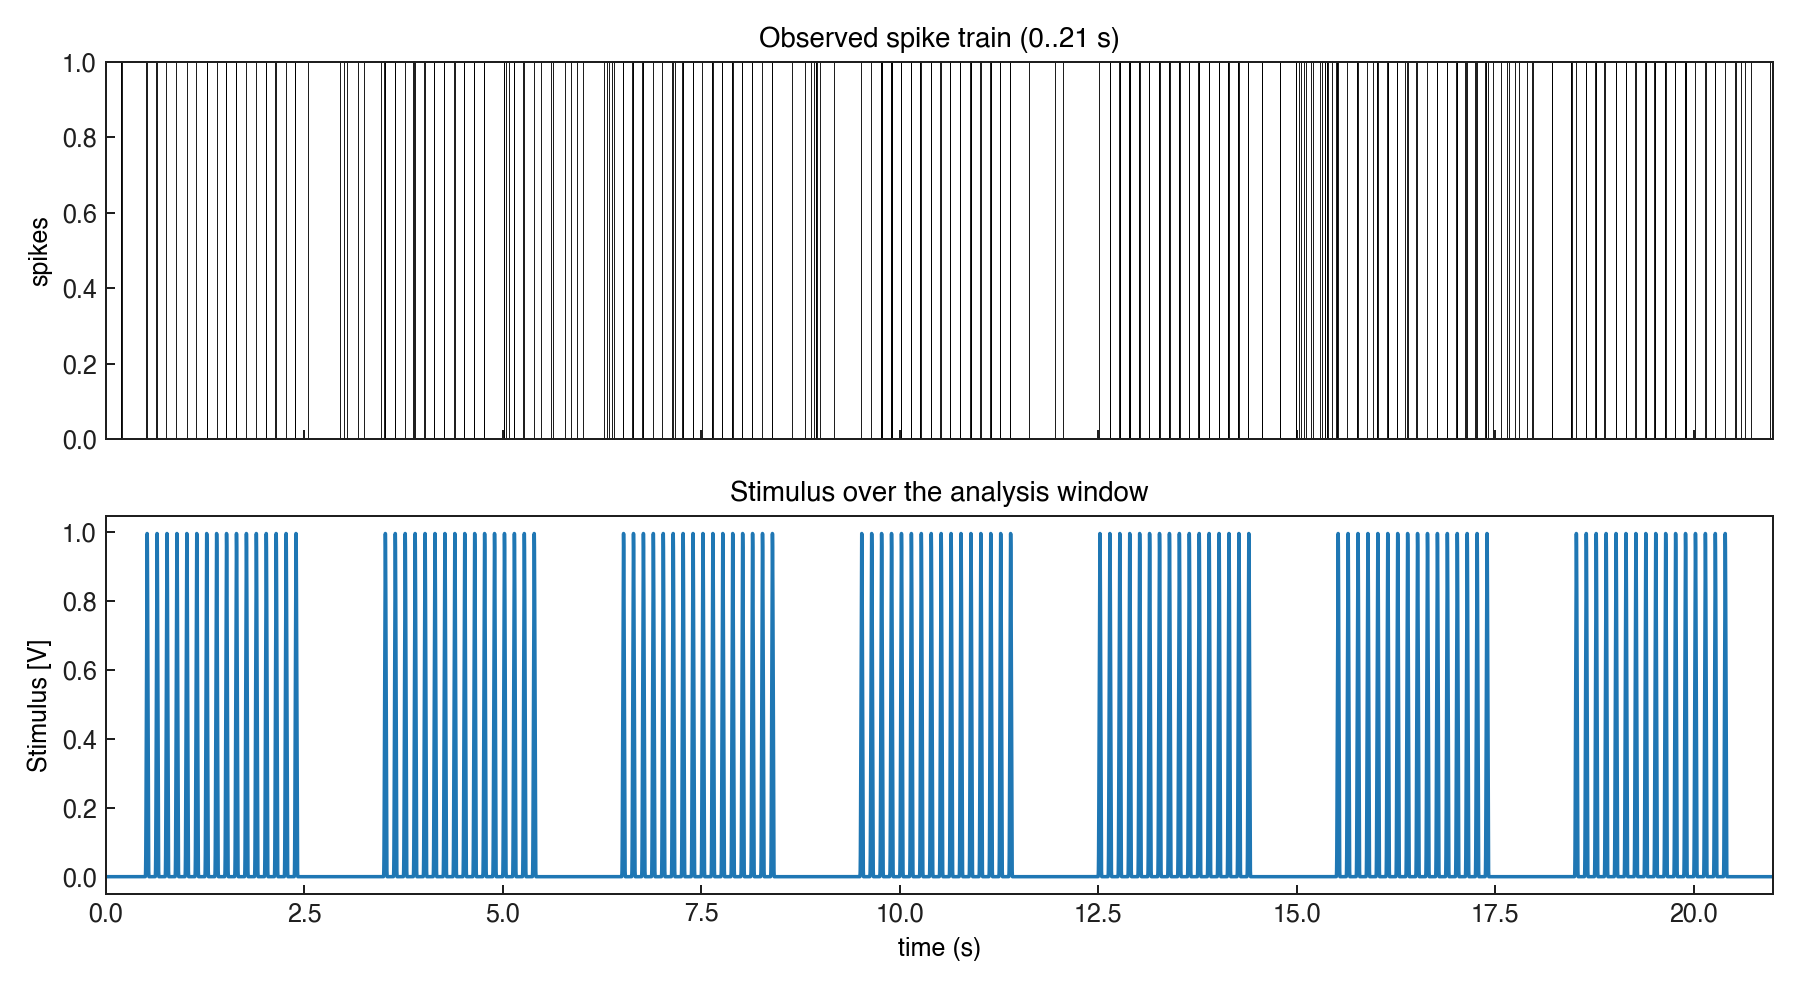

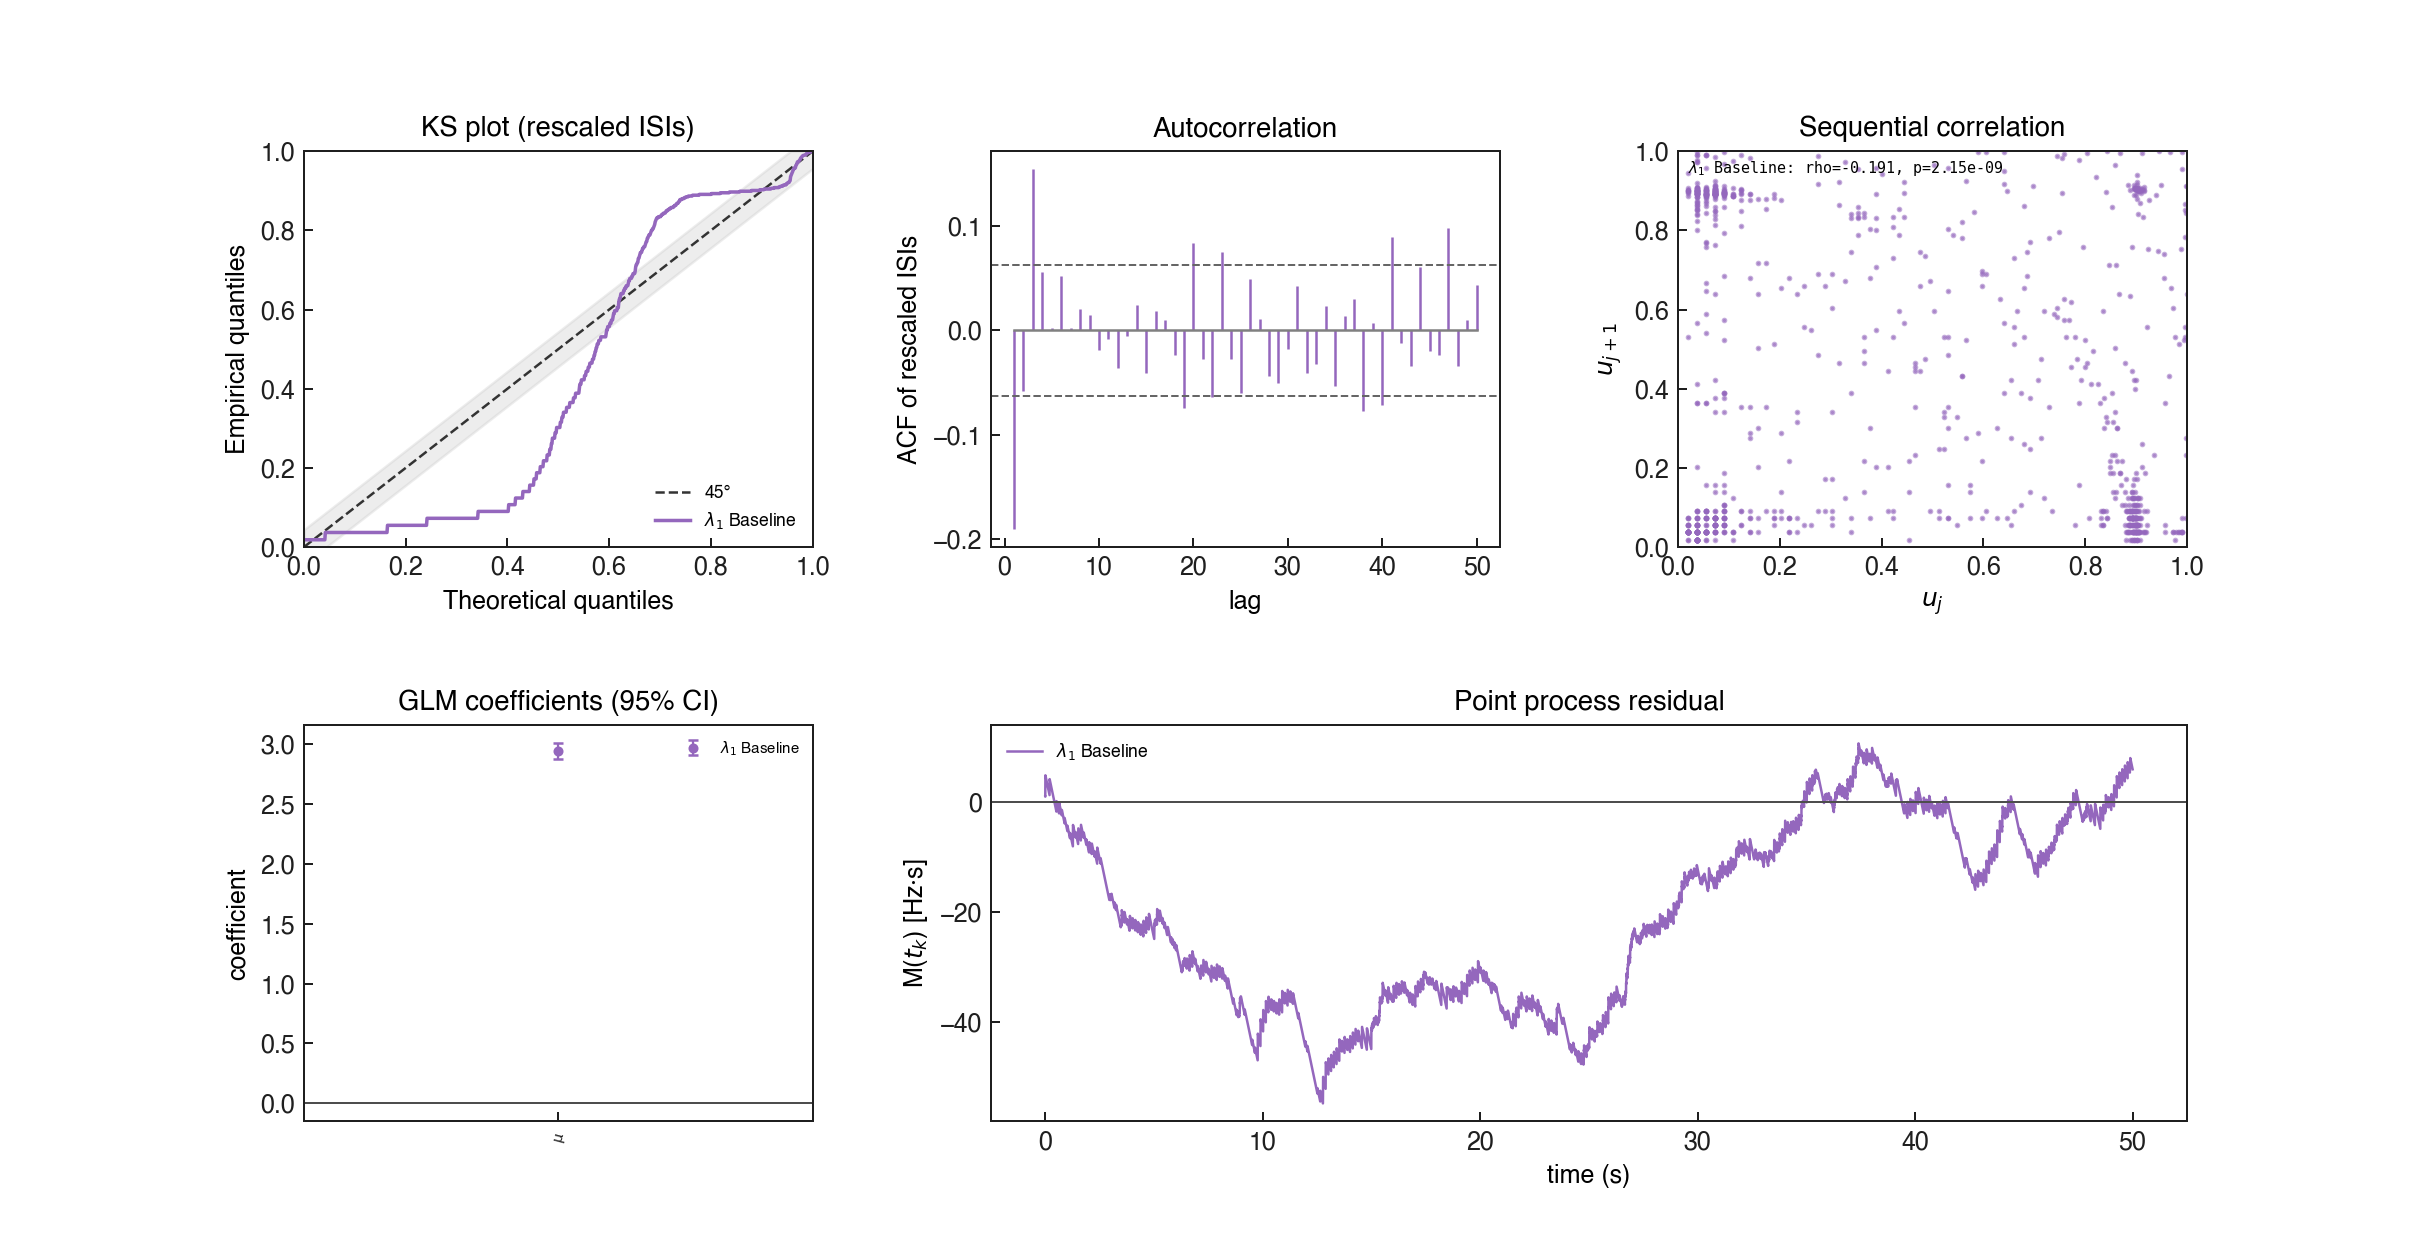

In [ ]:
# SECTION 1: Load the data
# MATLAB fig 1 (trial.plot): raster (left) | Stimulus[V] + Baseline=1 stacked (right)
fig = _prepare_figure("trial.plot", figsize=(10.0, 5.5))
gs = fig.add_gridspec(2, 2, width_ratios=[1.0, 1.4], hspace=0.25, wspace=0.3)
ax_raster = fig.add_subplot(gs[:, 0])
time_arr = np.asarray(payload["time_s"], dtype=float)
spike_arr = np.asarray(payload["spike_indicator"], dtype=float)
spike_times = time_arr[spike_arr > 0.5]
if spike_times.size:
    ax_raster.vlines(spike_times, 0.5, 1.5, color="k", linewidth=0.35)
ax_raster.set_ylim(0.0, 2.0)
ax_raster.set_yticks([1.0])
ax_raster.set_yticklabels(["1"])
ax_raster.set_ylabel("neuron")
ax_raster.set_xlabel("time (s)")
ax_raster.set_title("spike train")
ax_stim = fig.add_subplot(gs[0, 1])
ax_stim.plot(time_arr, payload["stimulus"], color="tab:blue", linewidth=1.25)
ax_stim.set_ylabel("Stimulus [V]")
ax_stim.set_title("Stimulus")
ax_base = fig.add_subplot(gs[1, 1], sharex=ax_stim)
ax_base.plot(time_arr, np.ones_like(time_arr), color="tab:gray", linewidth=1.25)
ax_base.set_ylabel("Baseline")
ax_base.set_xlabel("time (s)")
ax_base.set_ylim(0.0, 1.5)

# MATLAB fig 2: spike train clipped to 21s + stim.getSigInTimeWindow(0,21).plot
fig = _prepare_figure("stim.getSigInTimeWindow(0,21).plot", figsize=(10.0, 5.5))
axs = fig.subplots(2, 1, sharex=True)
_plot_spike_indicator(axs[0], payload["time_s"], payload["spike_indicator"])
axs[0].set_title("Observed spike train (0..21 s)")
axs[1].plot(payload["time_s"], payload["stimulus"], color="tab:blue", linewidth=1.4)
axs[1].set_title("Stimulus over the analysis window")
axs[1].set_ylabel("Stimulus [V]")
axs[1].set_xlabel("time (s)")
axs[1].set_xlim(0.0, 21.0)

# Fit a constant baseline and Find Stimulus Lag

We fit a constant rate (Poisson) model to the data and use the fit residual to determine the appropriate lag for the stimulus.

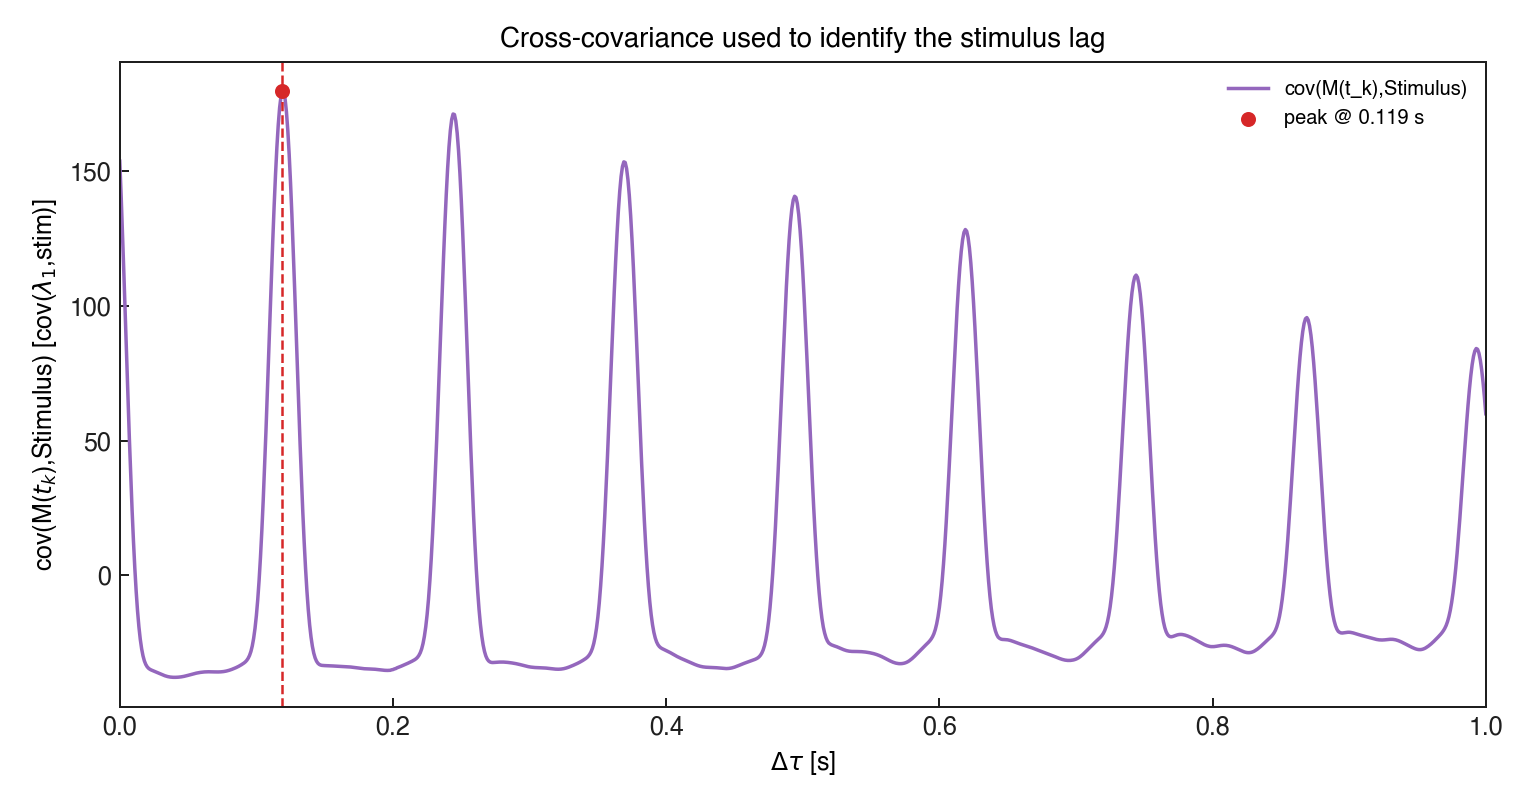

In [ ]:
# SECTION 2: Fit a constant baseline and Find Stimulus Lag
# MATLAB results.plotResults: full 5-panel dashboard (KS / ACF / SeqCorr / GLM coeffs / Residual).
fig = _prepare_figure("results.plotResults", figsize=(13.5, 7.0))
_plot_results_dashboard(
    fig,
    payload,
    models=[
        (
            r"$\lambda_1$ Baseline",
            "tab:purple",
            payload["ks_const_empirical"],
            payload["acf_m1"],
            payload["seq_corr_m1"],
            payload["glm_m1"],
            payload["residual_m1"],
        ),
    ],
)


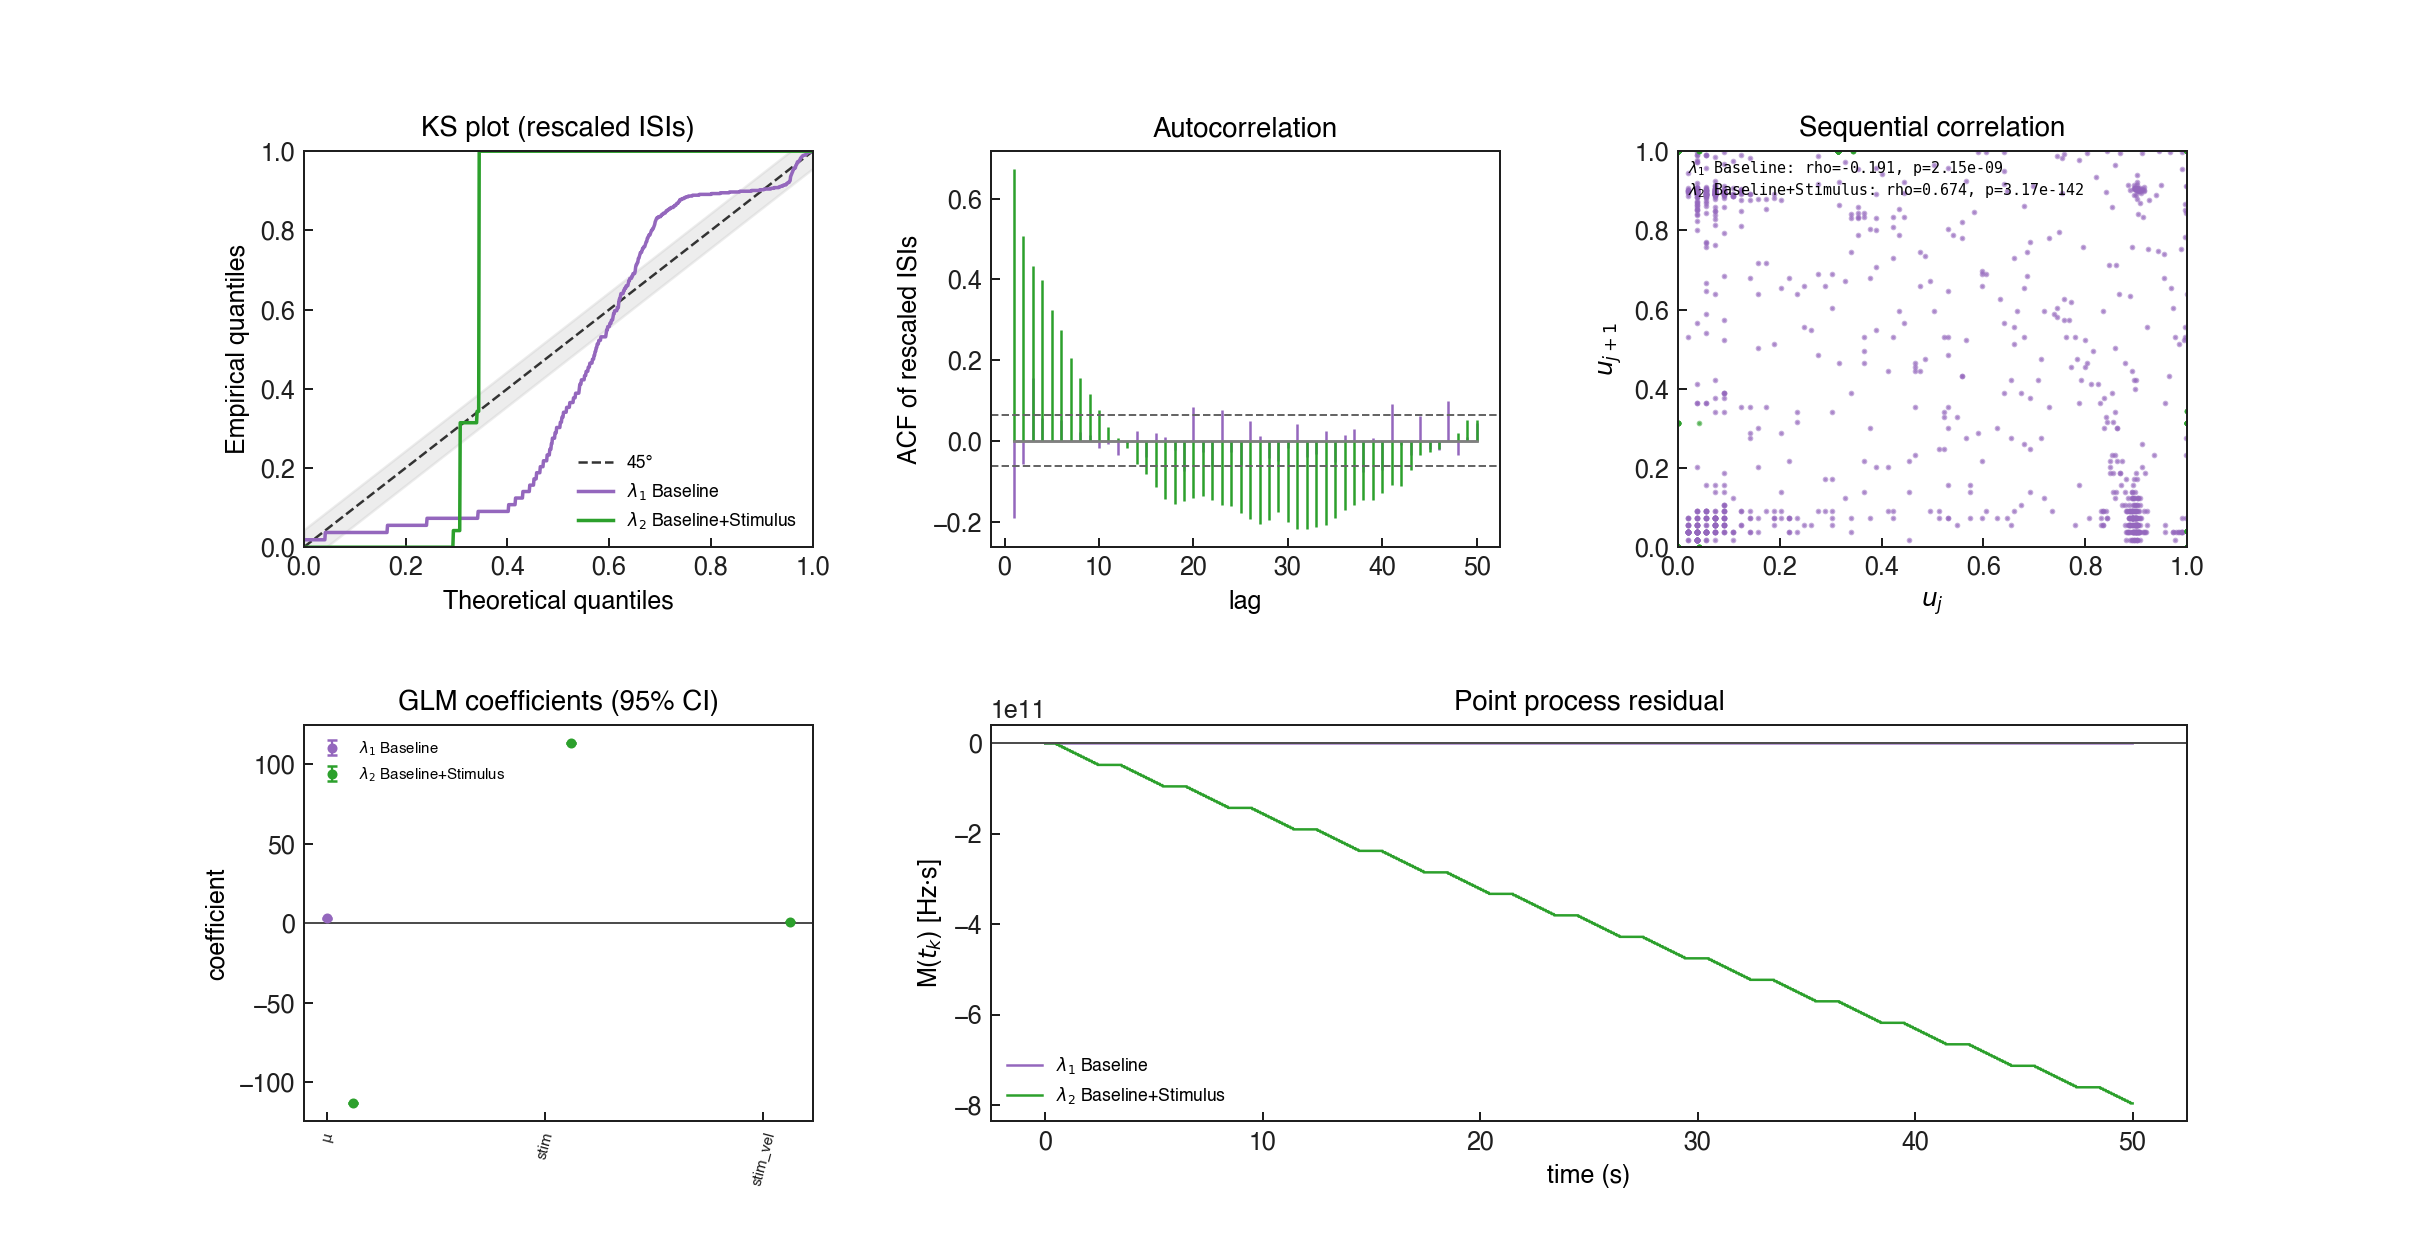

In [ ]:
# MATLAB: results.Residual.xcov(stim).windowedSignal([0,1]).plot
fig = _prepare_figure("results.Residual.xcov(stim).windowedSignal([0,1]).plot", figsize=(8.5, 4.5))
ax = fig.subplots(1, 1)
lags_s = np.asarray(payload["xcorr_lags_s"], dtype=float)
xcorr_vals = np.asarray(payload["xcorr_values"], dtype=float)
# clip to the 0..1 s window MATLAB uses
keep = (lags_s >= 0.0) & (lags_s <= 1.0)
lags_s = lags_s[keep]
xcorr_vals = xcorr_vals[keep]
peak_idx = int(np.argmax(xcorr_vals))
ax.plot(lags_s, xcorr_vals, color="tab:purple", linewidth=1.4, label="cov(M(t_k),Stimulus)")
ax.axvline(lags_s[peak_idx], color="tab:red", linestyle="--", linewidth=1.0)
ax.scatter([lags_s[peak_idx]], [xcorr_vals[peak_idx]], color="tab:red", zorder=3, label=f"peak @ {lags_s[peak_idx]:.3f} s")
ax.set_title("Cross-covariance used to identify the stimulus lag")
ax.set_xlabel(r"$\Delta\tau$ [s]")
ax.set_ylabel(r"cov(M($t_k$),Stimulus) [cov($\lambda_1$,stim)]")
ax.set_xlim(0.0, 1.0)
ax.legend(loc="upper right", frameon=False, fontsize=8)

# Compare constant rate model with model including stimulus effect

Addition of the stimulus improves the fits in terms of the KS plot and the making the rescaled ISIs less correlated. The Point Process Residula also looks more "white"

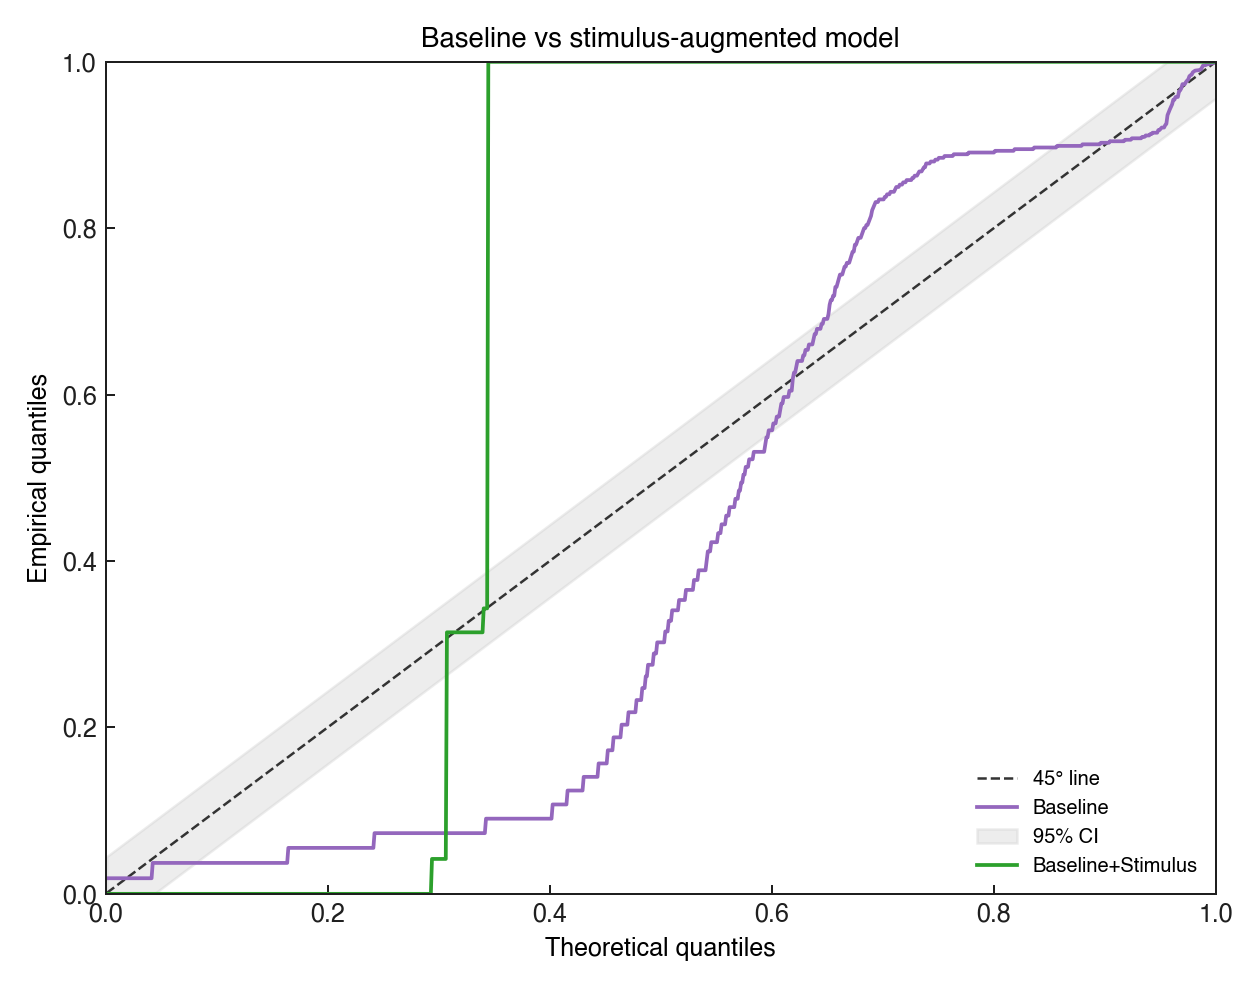

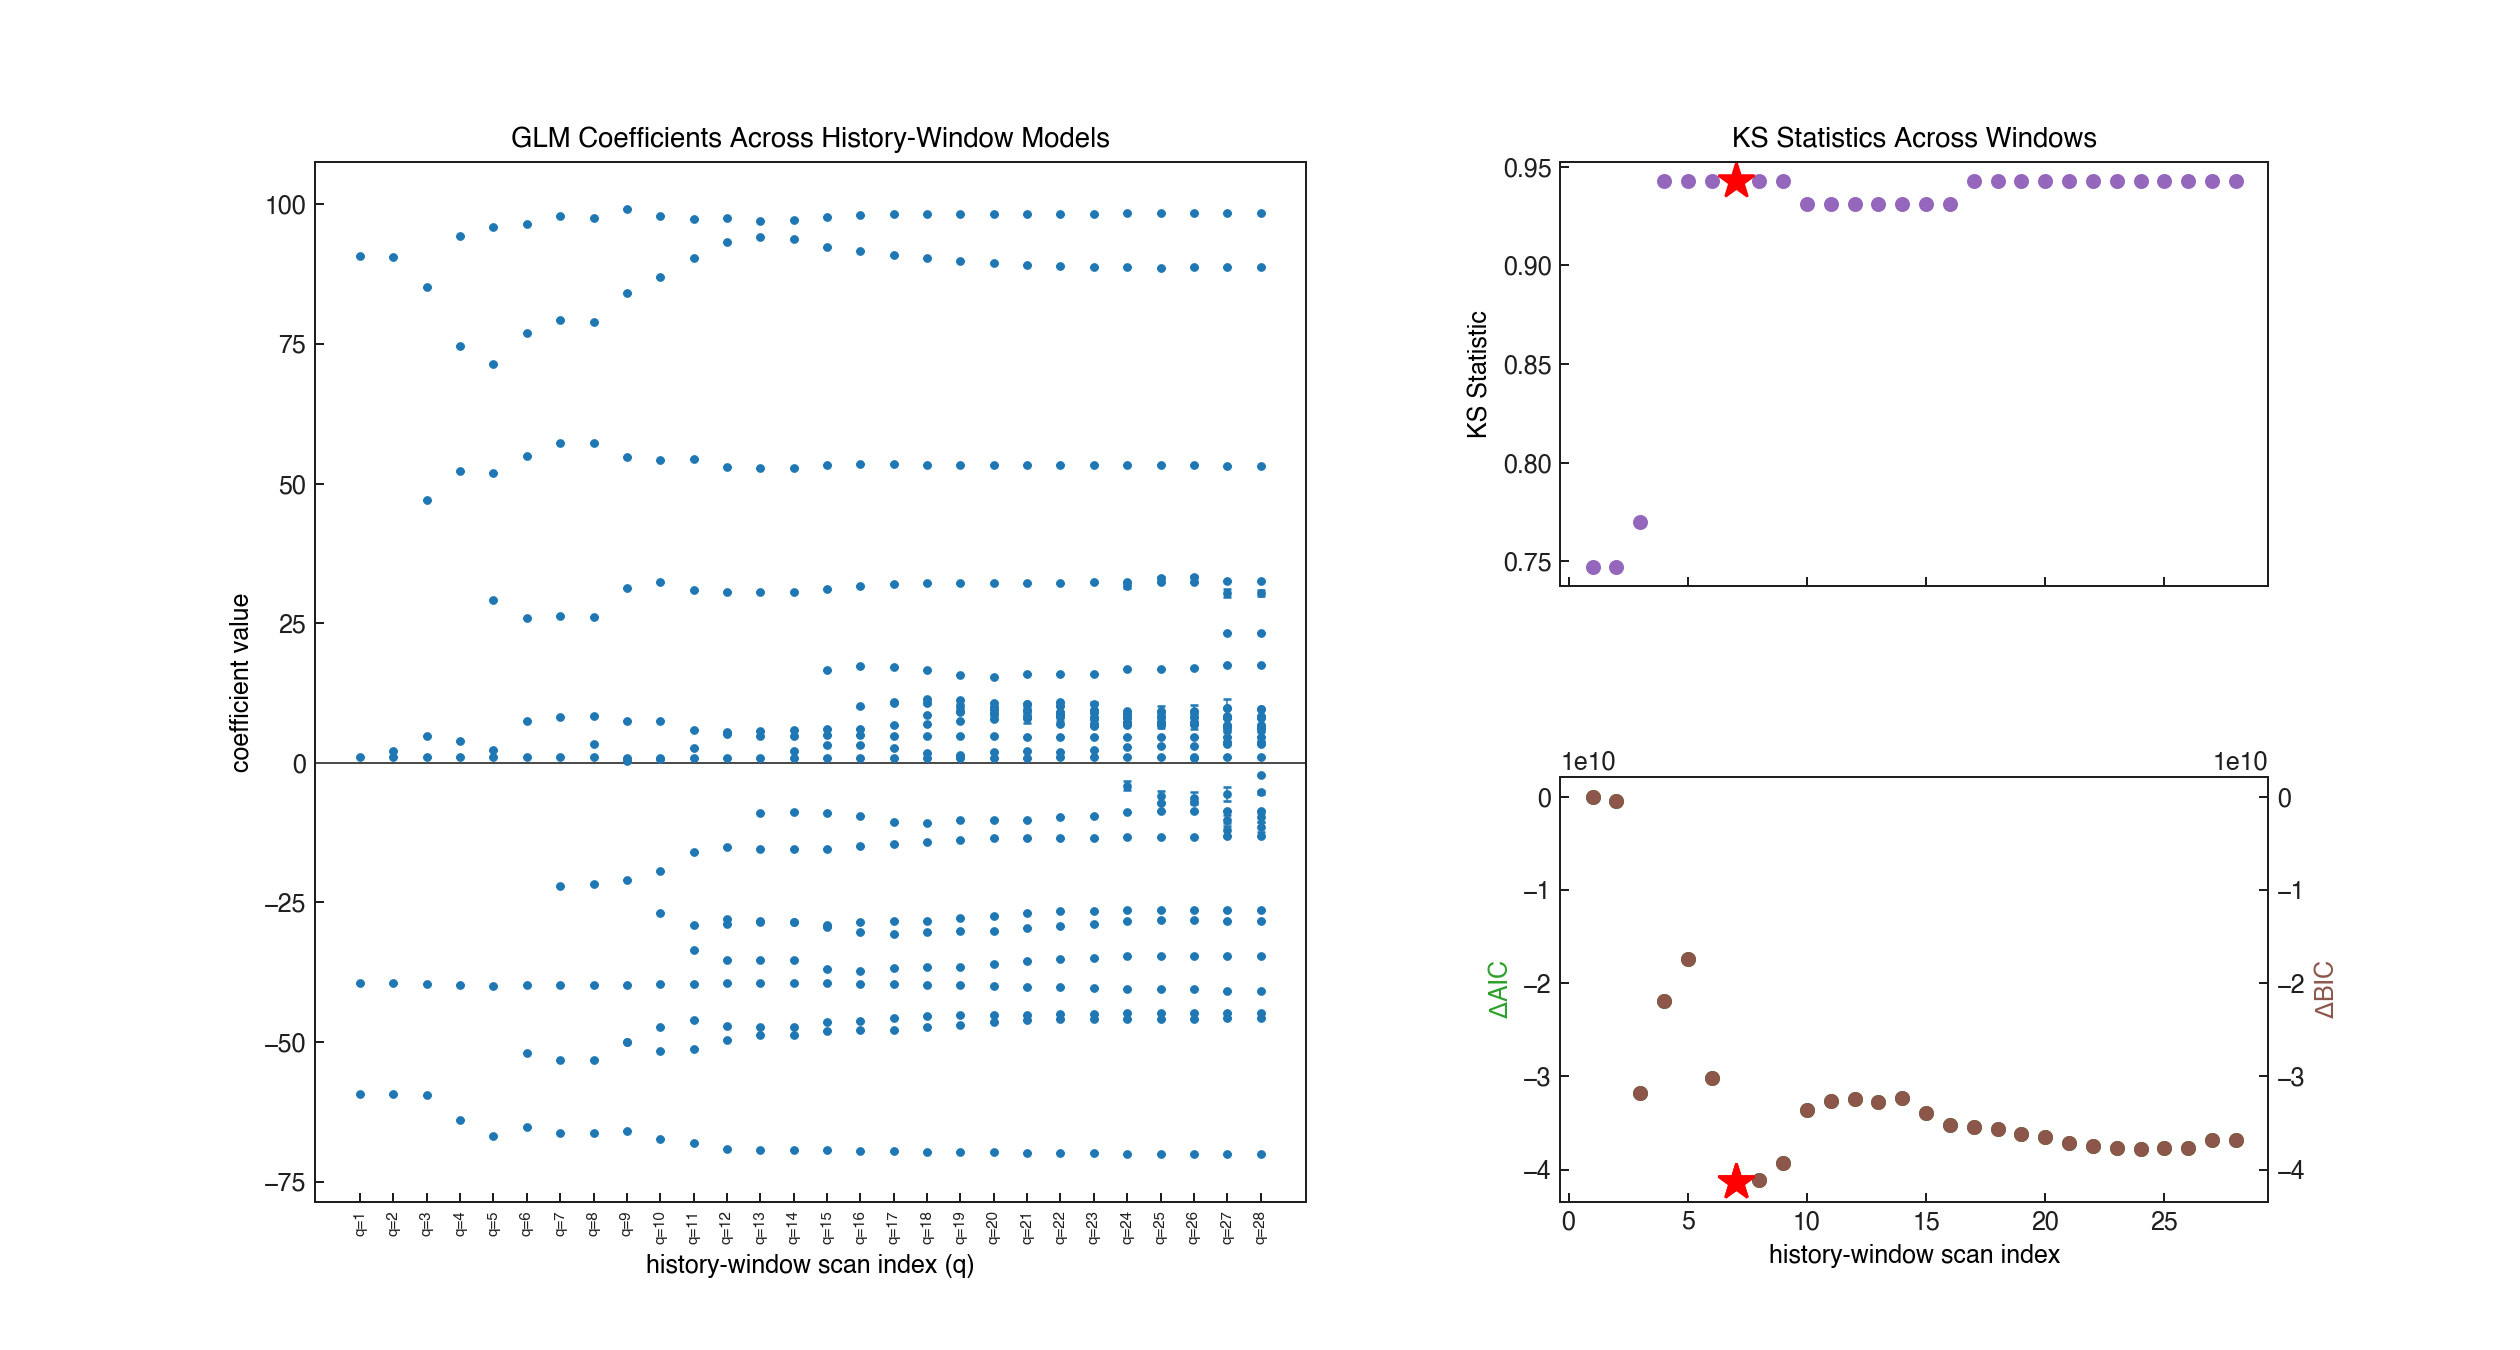

In [ ]:
# SECTION 3: Compare constant rate model with model including stimulus effect
# MATLAB results.plotResults overlay (lambda_1 baseline vs lambda_2 baseline+stim).
fig = _prepare_figure("results.plotResults", figsize=(13.5, 7.0))
_plot_results_dashboard(
    fig,
    payload,
    models=[
        (
            r"$\lambda_1$ Baseline",
            "tab:purple",
            payload["ks_const_empirical"],
            payload["acf_m1"],
            payload["seq_corr_m1"],
            payload["glm_m1"],
            payload["residual_m1"],
        ),
        (
            r"$\lambda_2$ Baseline+Stimulus",
            "tab:green",
            payload["ks_stim_empirical"],
            payload["acf_m2"],
            payload["seq_corr_m2"],
            payload["glm_m2"],
            payload["residual_m2"],
        ),
    ],
)

# Python-only summary: KS overlay alone for quick comparison.
fig = _prepare_figure("results.plotResults", figsize=(7.0, 5.5))
ax = fig.subplots(1, 1)
_plot_ks(ax, payload["ks_ideal"], payload["ks_const_empirical"], payload["ks_ci"], label="Baseline", color="tab:purple")
ax.plot(np.asarray(payload["ks_ideal"], dtype=float), np.asarray(payload["ks_stim_empirical"], dtype=float), color="tab:green", linewidth=1.5, label="Baseline+Stimulus")
ax.set_title("Baseline vs stimulus-augmented model")
ax.legend(loc="lower right", frameon=False, fontsize=8)


# History Effect

Determine the best history effect model using AIC, BIC, and KS statistic

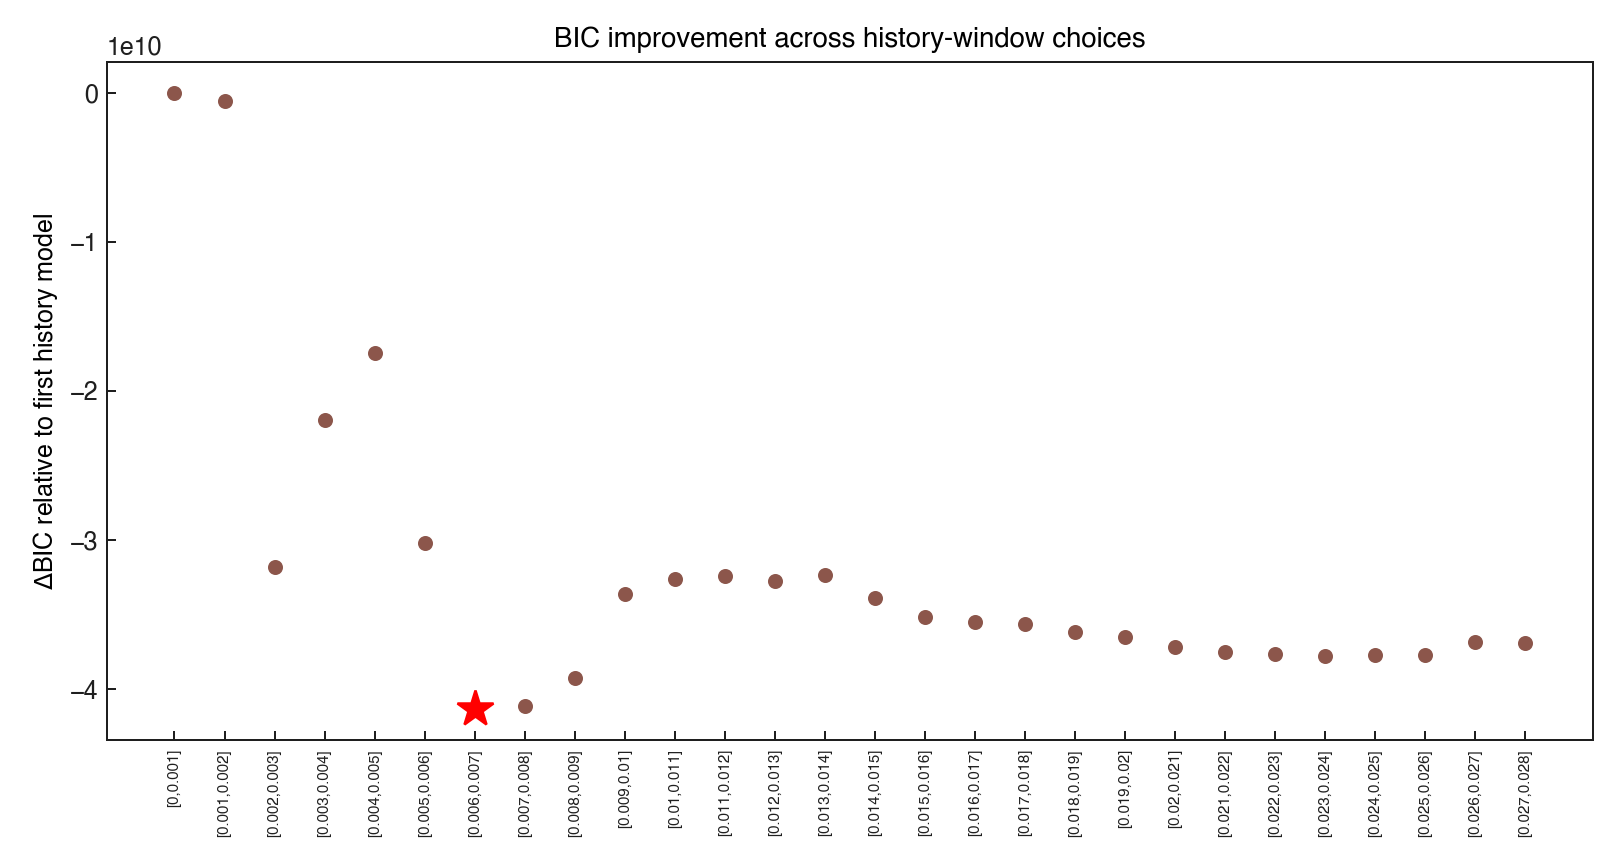

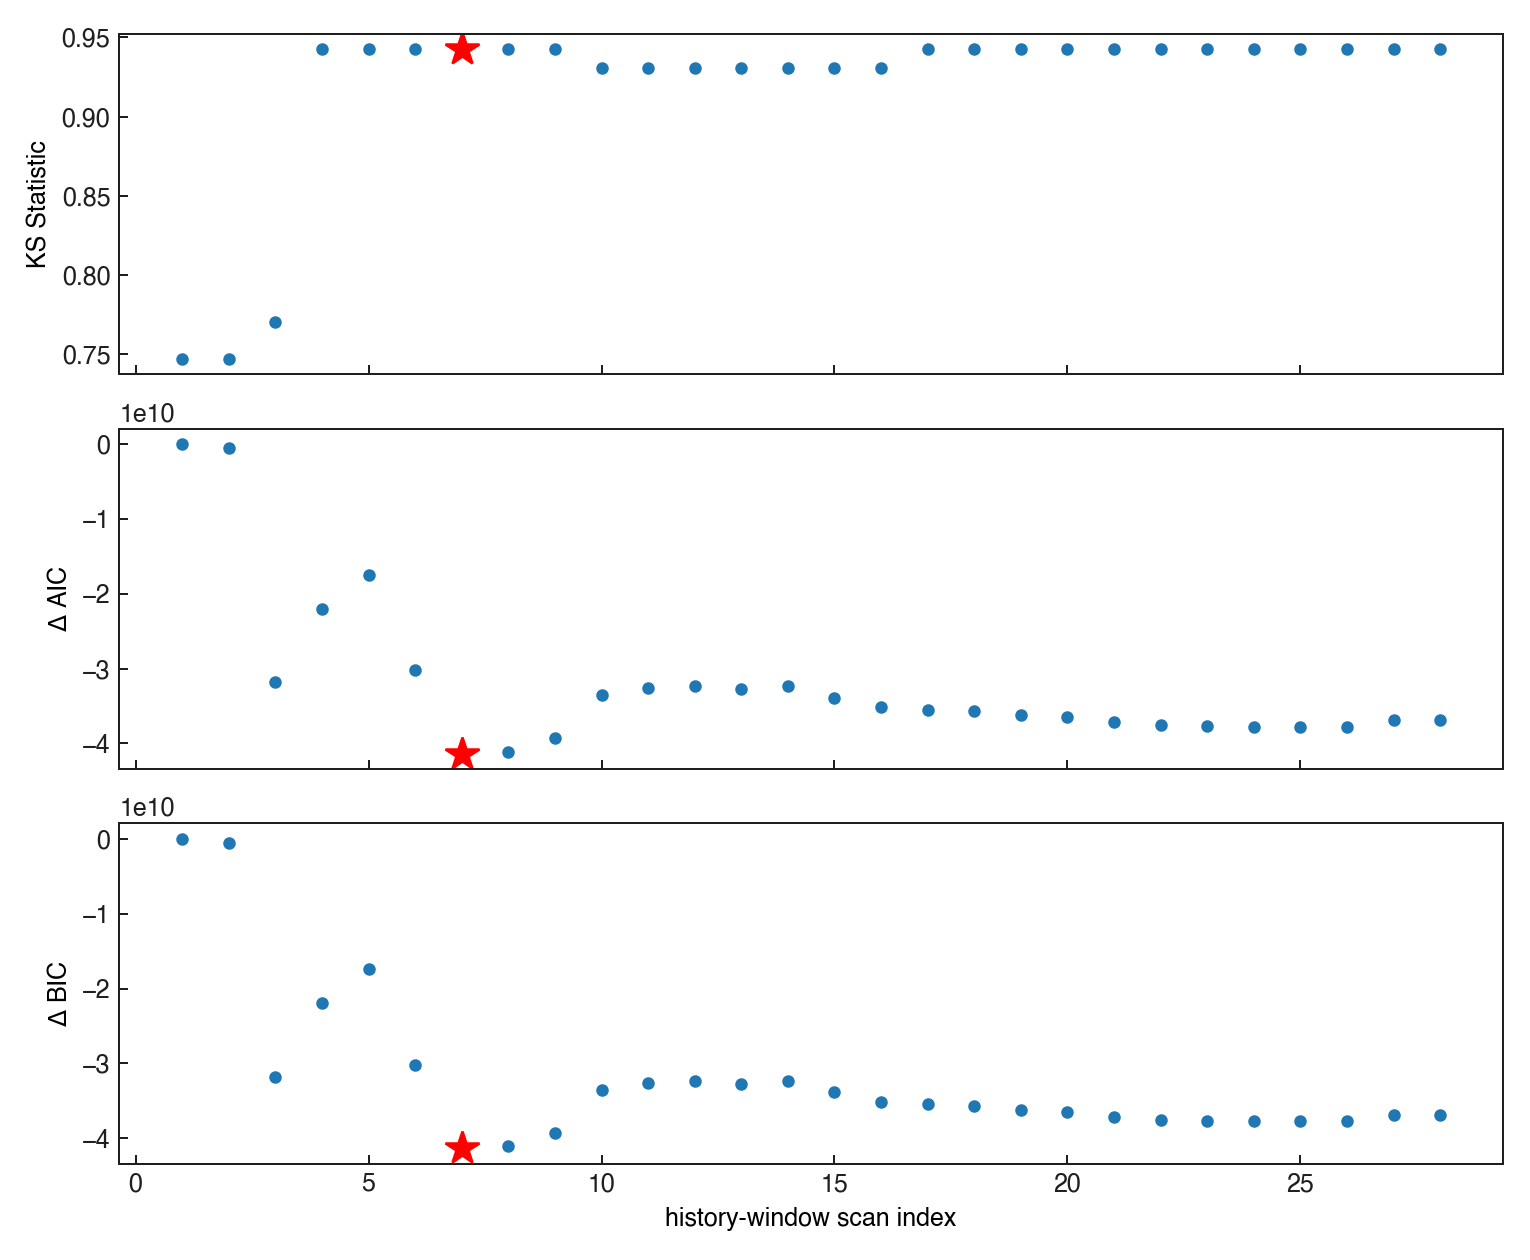

In [ ]:
# SECTION 4: History Effect
# MATLAB Summary.plotSummary — 4-panel dashboard:
#   left (tall) = GLM Coefficients Across Neurons (one column per history window),
#   top-right   = KS Statistics Across Neurons per Window,
#   bottom-right (twin panels) = dAIC and dBIC Across Neurons.
fig = _prepare_figure("Summary.plotSummary", figsize=(14.0, 7.5))
gs = fig.add_gridspec(2, 2, width_ratios=[1.4, 1.0], hspace=0.45, wspace=0.3)
ax_glm = fig.add_subplot(gs[:, 0])
ax_ks = fig.add_subplot(gs[0, 1])
ax_ic = fig.add_subplot(gs[1, 1])

history_windows = np.asarray(payload["history_windows"], dtype=float)
xidx = np.arange(1, history_windows.size + 1, dtype=float)
ks_arr = np.asarray(payload["ks_stats"], dtype=float)
daic_arr = np.asarray(payload["delta_aic"], dtype=float)
dbic_arr = np.asarray(payload["delta_bic"], dtype=float)

# Left: per-window GLM coefficient errorbars (history bins + μ/stim/stim_vel).
# Lay out one column per window index along x; each coefficient gets its own row in y.
scan_values = payload["scan_coef_values"]
scan_lower = payload["scan_coef_lower"]
scan_upper = payload["scan_coef_upper"]
scan_names = payload["scan_coef_names"]
# Use the LAST (widest) scan as canonical label set so all coefficients appear.
canon_names = list(scan_names[-1])
canon_index = {name: i for i, name in enumerate(canon_names)}
for col, (vals, low, up, names) in enumerate(zip(scan_values, scan_lower, scan_upper, scan_names)):
    vals = np.asarray(vals, dtype=float)
    low = np.asarray(low, dtype=float)
    up = np.asarray(up, dtype=float)
    for v, lo, hi, nm in zip(vals, low, up, names):
        y = canon_index.get(nm, None)
        if y is None:
            continue
        ax_glm.errorbar(col + 1, v, yerr=[[v - lo], [hi - v]], fmt="o", color="tab:blue", markersize=2.5, capsize=1.5, linewidth=0.6)
ax_glm.axhline(0.0, color="0.3", linewidth=0.8)
ax_glm.set_xticks(xidx)
ax_glm.set_xticklabels([f"q={int(q)}" for q in history_windows], rotation=90, fontsize=6)
ax_glm.set_xlabel("history-window scan index (q)")
ax_glm.set_ylabel("coefficient value")
ax_glm.set_title("GLM Coefficients Across History-Window Models")

# Top-right: KS scan
ax_ks.plot(xidx, ks_arr, marker=".", linestyle="none", color="tab:purple", markersize=10)
ax_ks.plot(xidx[best_history_idx], ks_arr[best_history_idx], "*", color="red", markersize=15, markeredgecolor="red")
ax_ks.set_ylabel("KS Statistic")
ax_ks.set_title("KS Statistics Across Windows")
ax_ks.tick_params(labelbottom=False)

# Bottom-right: dAIC + dBIC on twin axes
ax_ic.plot(xidx, daic_arr, marker=".", linestyle="none", color="tab:green", markersize=10, label=r"$\Delta$AIC")
ax_ic.plot(xidx[best_history_idx], daic_arr[best_history_idx], "*", color="red", markersize=15, markeredgecolor="red")
ax_ic2 = ax_ic.twinx()
ax_ic2.plot(xidx, dbic_arr, marker=".", linestyle="none", color="tab:brown", markersize=10, label=r"$\Delta$BIC")
ax_ic2.plot(xidx[best_history_idx], dbic_arr[best_history_idx], "*", color="red", markersize=15, markeredgecolor="red")
ax_ic.set_ylabel(r"$\Delta$AIC", color="tab:green")
ax_ic2.set_ylabel(r"$\Delta$BIC", color="tab:brown")
ax_ic.set_xlabel("history-window scan index")

# MATLAB dBIC plot with rotated [a,b] window labels at 90 degrees
fig = _prepare_figure("plot(x,dBIC,'.')", figsize=(9.0, 4.8))
ax = fig.subplots(1, 1)
ax.plot(xidx, dbic_arr, marker=".", linestyle="none", color="tab:brown", markersize=10)
ax.plot(xidx[best_history_idx], dbic_arr[best_history_idx], "*", color="red", markersize=15, markeredgecolor="red")
# MATLAB uses [lo,hi] window labels; here history_windows holds the upper bin count
dt_bin = 0.001  # 1 ms bin from run_experiment2
lower_s = np.concatenate([[0.0], history_windows[:-1] * dt_bin])
upper_s = history_windows * dt_bin
labels = [f"[{lo:.3g},{hi:.3g}]" for lo, hi in zip(lower_s, upper_s)]
ax.set_xticks(xidx)
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_title("BIC improvement across history-window choices")
ax.set_ylabel(r"$\Delta$BIC relative to first history model")

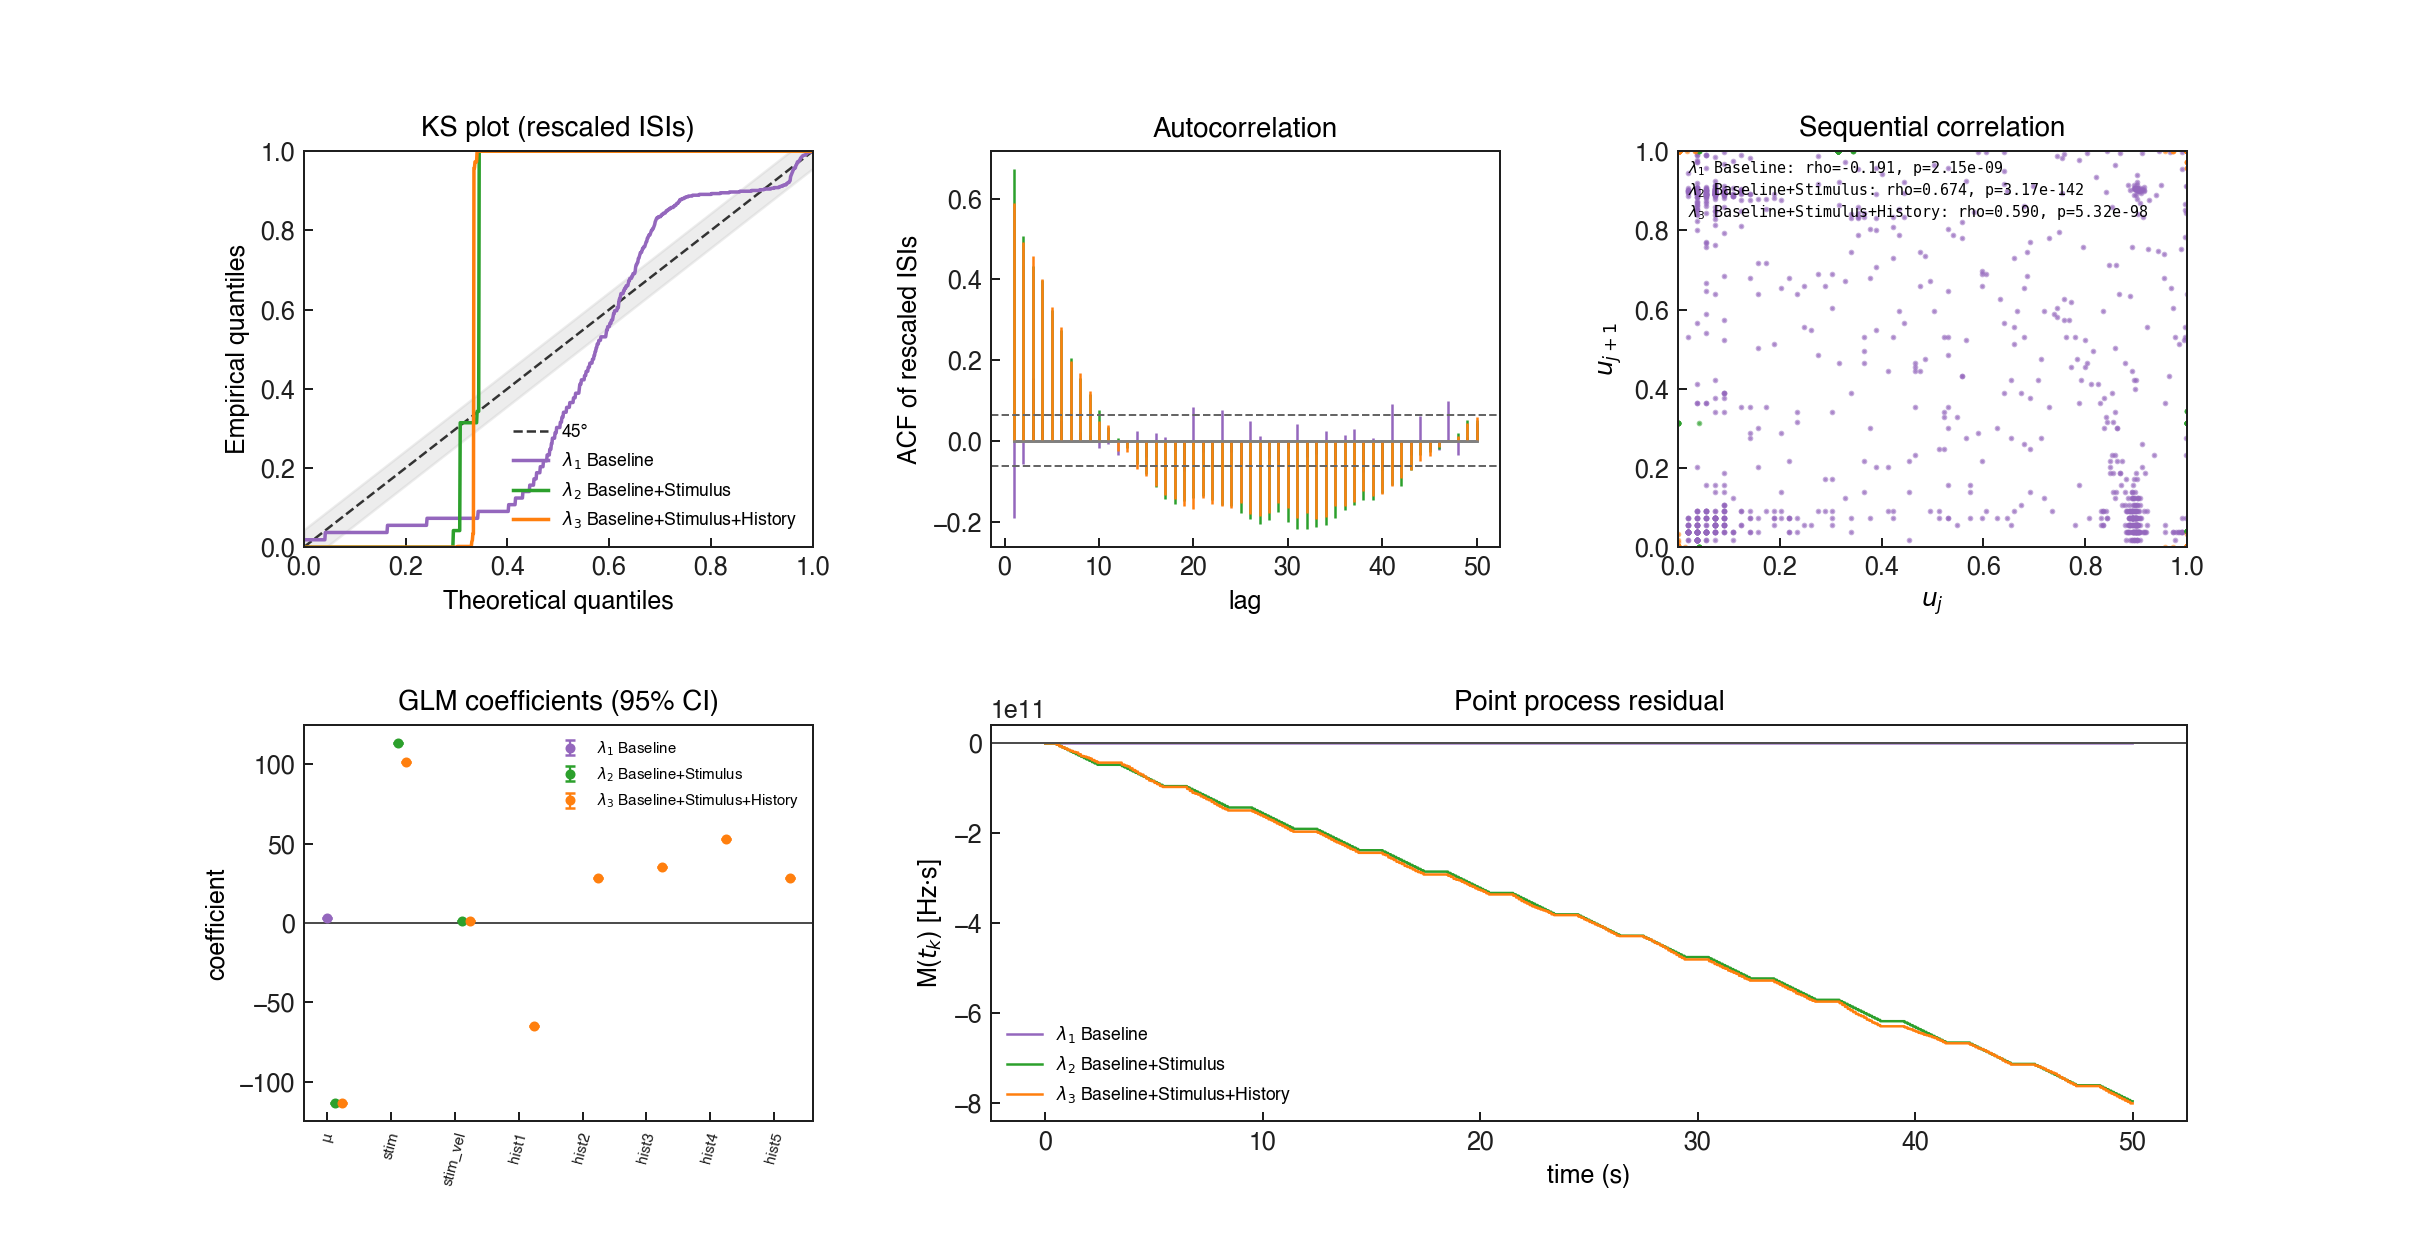

In [ ]:
# Mirrors MATLAB lines 113-128: subplot(3,1,1)=KS, subplot(3,1,2)=dAIC, subplot(3,1,3)=dBIC,
# with the chosen windowIndex flagged by a red '*' marker on each panel.
fig = _prepare_figure("subplot(3,1,k); plot(x,KS/dAIC/dBIC,'.')", figsize=(8.5, 7.0))
axes = fig.subplots(3, 1, sharex=True)
axes[0].plot(xidx, ks_arr, ".", color="tab:blue", markersize=8)
axes[0].plot(xidx[best_history_idx], ks_arr[best_history_idx], "*", color="red", markersize=14, markeredgecolor="red")
axes[0].set_ylabel("KS Statistic")
axes[0].tick_params(labelbottom=False)
axes[1].plot(xidx, daic_arr, ".", color="tab:blue", markersize=8)
axes[1].plot(xidx[best_history_idx], daic_arr[best_history_idx], "*", color="red", markersize=14, markeredgecolor="red")
axes[1].set_ylabel(r"$\Delta$ AIC")
axes[1].tick_params(labelbottom=False)
axes[2].plot(xidx, dbic_arr, ".", color="tab:blue", markersize=8)
axes[2].plot(xidx[best_history_idx], dbic_arr[best_history_idx], "*", color="red", markersize=14, markeredgecolor="red")
axes[2].set_ylabel(r"$\Delta$ BIC")
axes[2].set_xlabel("history-window scan index")

# Compare Baseline, Baseline+Stimulus Model, Baseline+History+Stimulus

Addition of the history effect yields a model that falls within the 95% CI of the KS plot.

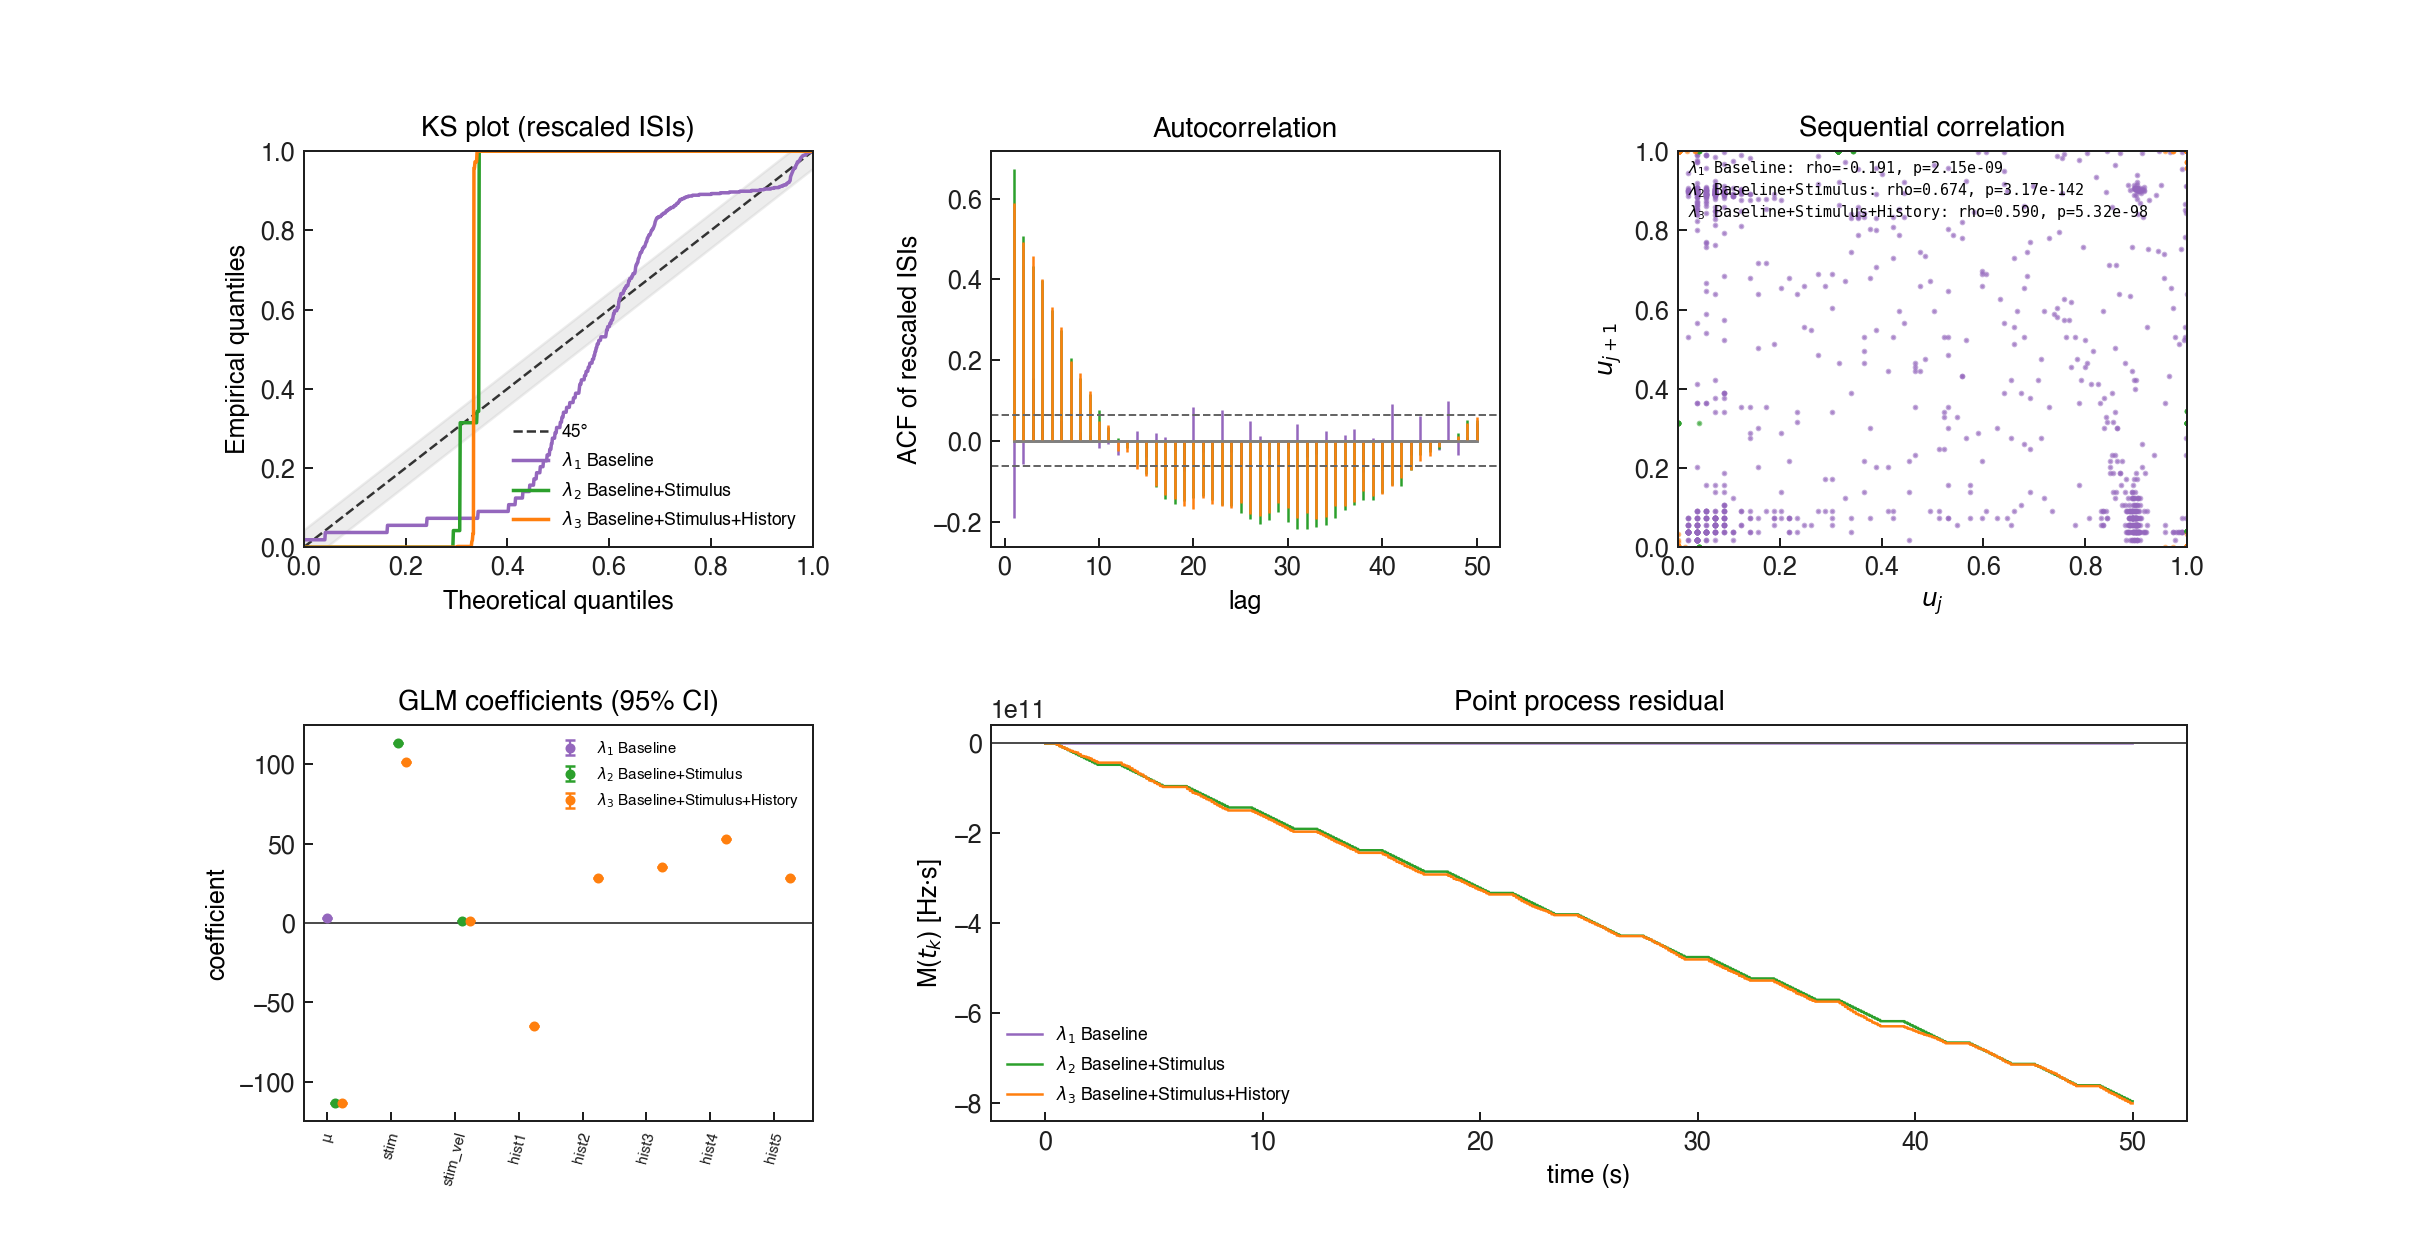

In [ ]:
# SECTION 5: Compare Baseline, Baseline+Stimulus Model, Baseline+History+Stimulus
# MATLAB results.plotResults (first call): 3-model 5-panel dashboard overlay.
fig = _prepare_figure("results.plotResults", figsize=(13.5, 7.0))
_plot_results_dashboard(
    fig,
    payload,
    models=[
        (
            r"$\lambda_1$ Baseline",
            "tab:purple",
            payload["ks_const_empirical"],
            payload["acf_m1"],
            payload["seq_corr_m1"],
            payload["glm_m1"],
            payload["residual_m1"],
        ),
        (
            r"$\lambda_2$ Baseline+Stimulus",
            "tab:green",
            payload["ks_stim_empirical"],
            payload["acf_m2"],
            payload["seq_corr_m2"],
            payload["glm_m2"],
            payload["residual_m2"],
        ),
        (
            r"$\lambda_3$ Baseline+Stimulus+History",
            "tab:orange",
            payload["ks_hist_empirical"],
            payload["acf_m3"],
            payload["seq_corr_m3"],
            payload["glm_m3"],
            payload["residual_m3"],
        ),
    ],
)

# MATLAB results.plotResults (second call) — canonical final dashboard. Render again as the
# end-of-example summary (parity with the second plotResults invocation), plus a synoptic KS overlay.
fig = _prepare_figure("results.plotResults", figsize=(13.5, 7.0))
_plot_results_dashboard(
    fig,
    payload,
    models=[
        (
            r"$\lambda_1$ Baseline",
            "tab:purple",
            payload["ks_const_empirical"],
            payload["acf_m1"],
            payload["seq_corr_m1"],
            payload["glm_m1"],
            payload["residual_m1"],
        ),
        (
            r"$\lambda_2$ Baseline+Stimulus",
            "tab:green",
            payload["ks_stim_empirical"],
            payload["acf_m2"],
            payload["seq_corr_m2"],
            payload["glm_m2"],
            payload["residual_m2"],
        ),
        (
            r"$\lambda_3$ Baseline+Stimulus+History",
            "tab:orange",
            payload["ks_hist_empirical"],
            payload["acf_m3"],
            payload["seq_corr_m3"],
            payload["glm_m3"],
            payload["residual_m3"],
        ),
    ],
)
__tracker.finalize()
